In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os
from mne.viz import plot_topomap

In [99]:
# Path to dataset folder
ROOT_DIR = os.getcwd()
data_folder = os.path.join(ROOT_DIR, "..", "data")
file_path = "derivatives/sub-001/eeg/sub-001_task-eyesclosed_eeg.set"

# Load the data of the first subject (001)
raw_001 = mne.io.read_raw_eeglab(
    os.path.join(
        data_folder,
        file_path
    ),
    preload=True  # load data into memory
)

print(raw_001)
print(type(raw_001))

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>
<class 'mne.io.eeglab.eeglab.RawEEGLAB'>


In [36]:
# Check the recording details  
raw_001.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>

In [37]:
# Check the fields names
print(raw_001.info.keys())

dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'dev_head_t', 'ch_names', 'nchan'])


In [38]:
# Check the channels
ch_names = raw_001.ch_names
n_chan = len(ch_names) 
print(f"The sample data object has {n_chan} channels.")
print("The channel names: {}.".format(", ".join(ch_names)))

The sample data object has 19 channels.
The channel names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, Fz, Cz, Pz.


In [39]:
# Check the chs field
print(raw_001.info["chs"][0].keys())

dict_keys(['loc', 'unit_mul', 'range', 'cal', 'kind', 'coil_type', 'unit', 'coord_frame', 'ch_name', 'scanno', 'logno'])


In [40]:
# Check the chs location
print(raw_001.info["chs"])

[{'loc': array([-0.0294367,  0.0839171, -0.00699  ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'Fp1', 'scanno': 1, 'logno': 1}, {'loc': array([ 0.0298723,  0.0848959, -0.00708  ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIFF_UNITM_NONE), 'range': 1.0, 'cal': 1e-06, 'kind': 2 (FIFFV_EEG_CH), 'coil_type': 1 (FIFFV_COIL_EEG), 'unit': 107 (FIFF_UNIT_V), 'coord_frame': 4 (FIFFV_COORD_HEAD), 'ch_name': 'Fp2', 'scanno': 2, 'logno': 2}, {'loc': array([-0.0502438,  0.0531112,  0.042192 ,  0.       ,  0.       ,
        0.       ,        nan,        nan,        nan,        nan,
              nan,        nan]), 'unit_mul': 0 (FIF

In [41]:
# Check the time samples
n_time_samples = raw_001.n_times
time_secs = raw_001.times
print(f"The sample data object has {n_time_samples} time samples")
print(f"The last time sample is at {time_secs[-1]} seconds.")

The sample data object has 299900 time samples
The last time sample is at 599.798 seconds.


In [42]:
# Check bad channels and frequencies
print("bad channels:", raw_001.info["bads"])   
print(raw_001.info["sfreq"], "Hz")   
print(raw_001.info["description"], )   

bad channels: []
500.0 Hz
None


In [43]:
# Convert a time in seconds into the integer index of the sample occuring closest to that time
print(raw_001.time_as_index(20))
print(raw_001.time_as_index([20, 30, 40]))

[10000]
[10000 15000 20000]


In [44]:
# The number of samples between time=1 second and time=2 seconds; the number of samples between time=2 and time=3
print(np.diff(raw_001.time_as_index([1, 2, 3])))

[500 500]


In [45]:
# Get the channel indices by including channel names
print(mne.pick_channels(raw_001.info["ch_names"], include=["Fp1", "Pz"]))

[ 0 18]


In [46]:
# Get the channle indices by excluding channel names
print(mne.pick_channels(raw_001.info["ch_names"], include=[], exclude=["Fp1", "Pz"]))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [47]:
# Get the channel indices by regular expressions
print(mne.pick_channels_regexp(raw_001.info["ch_names"], regexp="^O"))

[8, 9]


In [48]:
# Get the channel type
print(mne.channel_type(raw_001.info, 9))

eeg


In [49]:
# Extract data by index
sampling_freq = raw_001.copy().info["sfreq"]
print(sampling_freq)

start_stop_seconds = np.array([11, 13])
start_sample, stop_sample = (start_stop_seconds * sampling_freq).astype(int)  # MNE stores data in samples, not seconds
print(start_stop_seconds)
print(start_sample, stop_sample)

# Select the first channel
channel_index = 0
raw_selection = raw_001[channel_index, start_sample: stop_sample]  # MNE automatically converts samples indices to seconds to human understanding 
print(type(raw_selection))  # returns a tuple of two arrays

500.0
[11 13]
5500 6500
<class 'tuple'>


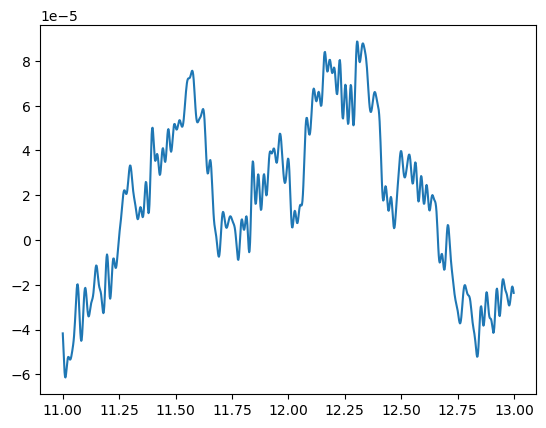

In [50]:
# Transpose the arrays for plotting
x = raw_selection[1]
y = raw_selection[0].T
plt.plot(x, y)
plt.show()

Amplitude (in microvolts (µV)): the strength of the voltage signal - how strong the electrical activity meansured at this scalp location at this moment. 

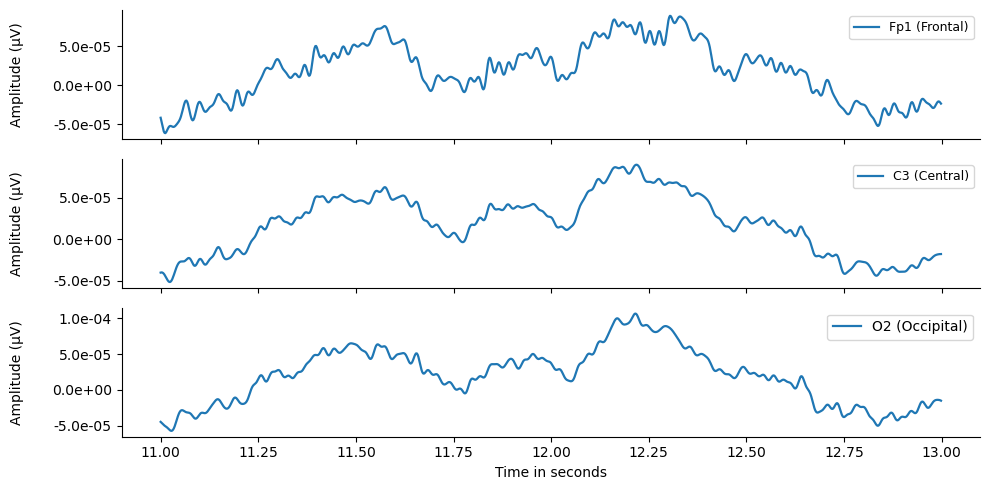

In [51]:
# Plot signals from three channels (Fp1, C3, O2)
import matplotlib.ticker as ticker

channel_index = mne.pick_channels(raw_001.info["ch_names"], include=["Fp1", "C3", "O2"])

sampling_freq = raw_001.copy().info["sfreq"]
start_stop_seconds = np.array([11, 13])
start_sample, stop_sample = (start_stop_seconds * sampling_freq).astype(int)

labels = ["Fp1 (Frontal)", "C3 (Central)", "O2 (Occipital)"]

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for i, ax in enumerate(axes):
    raw_selection = raw_001[channel_index[i], start_sample: stop_sample]
    x = raw_selection[1]
    y = raw_selection[0].T

    ax.plot(x, y, linewidth=1.6, label=labels[i])
    ax.set_ylabel("Amplitude (µV)", rotation=90, labelpad=20)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, 3))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    # ax.set_ylim(-1e-4, 1e-4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', labelsize=10)
    ax.legend(loc="upper right", fontsize=9)

axes[-1].legend(loc="upper right")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude (µV)")
plt.tight_layout()
fig.savefig("eeg_signals_3channels.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
# Extract data without the corresponding array of times
data = raw_001.get_data()
print(data.shape)  # (n_channels, n_timepoints)

(19, 299900)


In [53]:
# Extract both data and the array of times
data, times = raw_001.get_data(return_times=True)
print(data.shape)
print(times.shape)

(19, 299900)
(299900,)


In [54]:
# Check the data as Pandas DataFrame
df = raw_001.to_data_frame(start=start_sample, stop=stop_sample)  # then can be saved using df.to_csv() 
df.head(10)

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,11.000,-41.732258,-39.999573,-41.622650,-40.563297,-40.192795,-48.649910,-42.488411,-47.919563,-42.150787,-44.612080,-43.793621,-42.588768,-43.945145,-44.853275,-45.461487,-48.165939,-40.125374,-46.412846,-47.612862
1,11.002,-46.163109,-43.360279,-42.153908,-42.152290,-39.956966,-49.326172,-42.079086,-48.876354,-42.585175,-45.677963,-45.939800,-44.222221,-44.832714,-47.192699,-45.655239,-49.997791,-41.323578,-46.595264,-48.178097
2,11.004,-51.077541,-47.369595,-42.889751,-44.230576,-40.078133,-49.619328,-42.057842,-49.524872,-43.150673,-46.862446,-48.446747,-46.259319,-45.951500,-49.759727,-46.145664,-51.718655,-43.205891,-47.215172,-48.917057
3,11.006,-55.632591,-51.328381,-43.701923,-46.497669,-40.596153,-49.645031,-42.469891,-49.839497,-43.765285,-48.008202,-50.916542,-48.418205,-47.161987,-52.010891,-46.798592,-53.150337,-45.473606,-48.202484,-49.764065
4,11.008,-59.111633,-54.600811,-44.489670,-48.655457,-41.515411,-49.579990,-43.312328,-49.884178,-44.364502,-49.020523,-52.992126,-50.414253,-48.333241,-53.523426,-47.491211,-54.194580,-47.799061,-49.462410,-50.675781
5,11.010,-61.074486,-56.747379,-45.208179,-50.462666,-42.801392,-49.617702,-44.534374,-49.795792,-44.921486,-49.883396,-54.434479,-52.021484,-49.373535,-54.097240,-48.146950,-54.852608,-49.897041,-50.896618,-51.637280
6,11.012,-61.426804,-57.597420,-45.870777,-51.766819,-44.373981,-49.915283,-46.036648,-49.743465,-45.448750,-50.646492,-55.161388,-53.113083,-50.242386,-53.788467,-48.747570,-55.213409,-51.572639,-52.411072,-52.649864
7,11.014,-60.407661,-57.260380,-46.536060,-52.520897,-46.111000,-50.556576,-47.682407,-49.885643,-45.992645,-51.399632,-55.250740,-53.683517,-50.950565,-52.882298,-49.330051,-55.424957,-52.746822,-53.921494,-53.717133
8,11.016,-58.497864,-56.070129,-47.276291,-52.775486,-47.854866,-51.531559,-49.310318,-50.326672,-46.612164,-52.232330,-54.901646,-53.838509,-51.539558,-51.806236,-49.960098,-55.647385,-53.447865,-55.348740,-54.825169
9,11.018,-56.281563,-54.484238,-48.140945,-52.653942,-49.428364,-52.739834,-50.753323,-51.088493,-47.353466,-53.196709,-54.370178,-53.759071,-52.055607,-51.009869,-50.697144,-56.004791,-53.778923,-56.612751,-55.928535


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\xiaox\anaconda3\envs\thesis\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\xiaox\AppData\Local\Temp\ipykernel_29064\2862912891.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


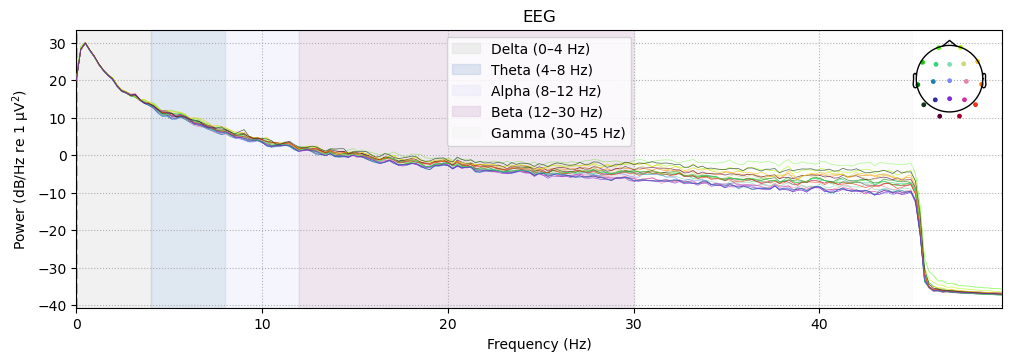

In [179]:
# Plot the power spectral density (PSD) and the time-domain EEG traces
fig1 = raw_001.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)  # compute the Power Spectral Density (PSD) up to 50 Hz for each channel
                                                                                  # picks="data": only EEG data channels
                                                                                  # exclude="bads": ignores channels marked as bad
                                                                                  # amplitude=False: plots in power units (µV²/Hz) instead of amplitude (µV/√Hz)
                                                                                  # Useful to quickly see band power differences (e.g., alpha peak ~10 Hz)
# Add shaded bands
ax = fig1.axes[0]
ax.axvspan(0, 4, color="gainsboro", alpha=0.4, label="Delta (0–4 Hz)")
ax.axvspan(4, 8, color="lightsteelblue", alpha=0.4, label="Theta (4–8 Hz)")
ax.axvspan(8, 12, color="lavender", alpha=0.4, label="Alpha (8–12 Hz)")
ax.axvspan(12, 30, color="thistle", alpha=0.4, label="Beta (12–30 Hz)")
ax.axvspan(30, 45, color="whitesmoke", alpha=0.4, label="Gamma (30–45 Hz)")

ax.legend(loc="upper center")

fig1.savefig("PSD for subject 001.png", dpi=300, bbox_inches='tight')
fig1.show()

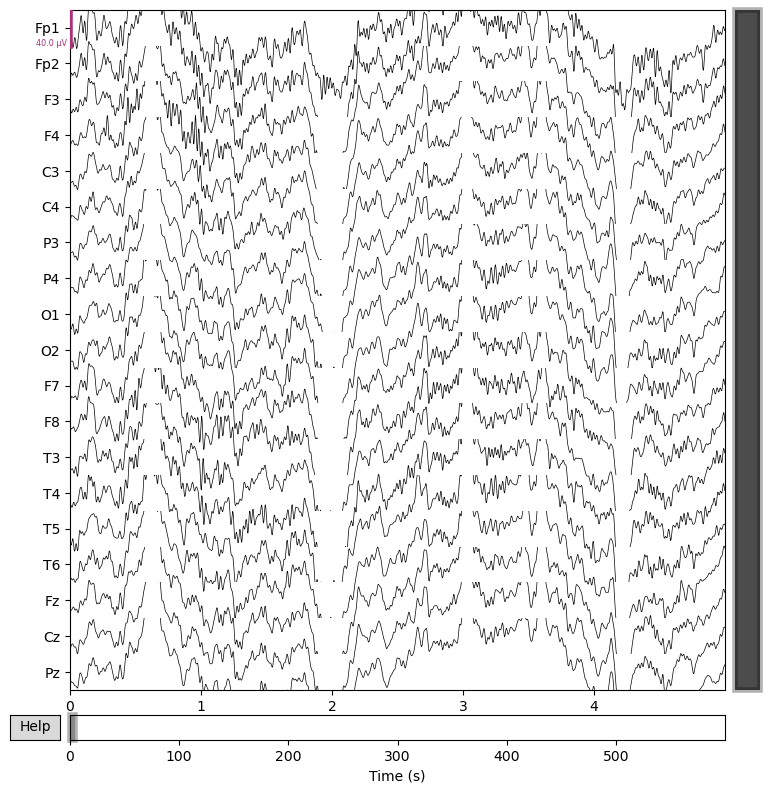

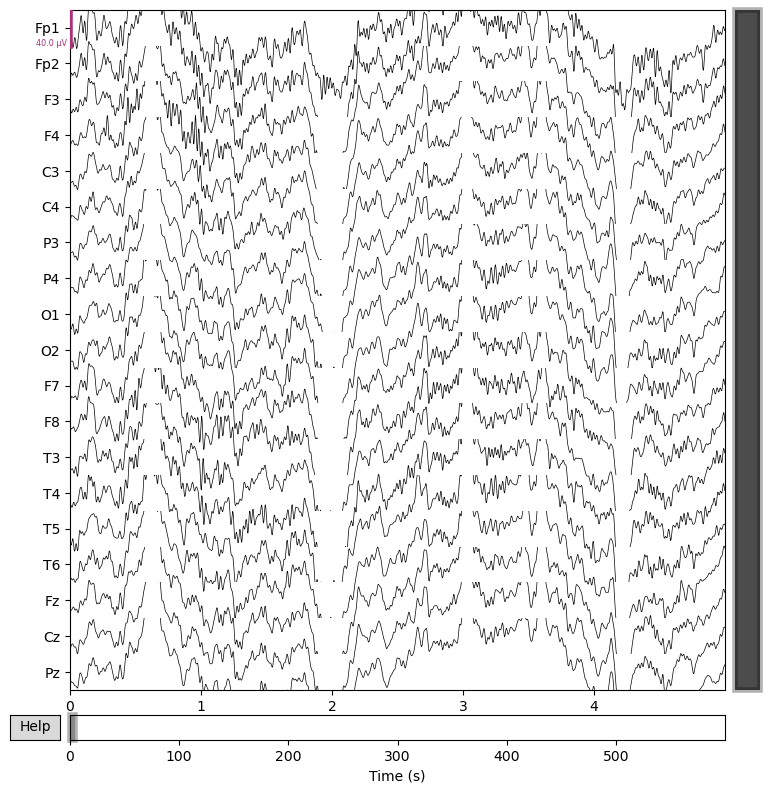

In [131]:
raw_001.plot(duration=5, n_channels=30)  # plot time-domain EEG traces
                                         # shows 30 channels over a 5s window

In [56]:
# List all the built-in EEG montages 
buildin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in buildin_montages:
    print(f"{montage_name}: {montage_description}")

standard_1005: Electrodes are named and positioned according to the international 10-05 system (343+3 locations)
standard_1020: Electrodes are named and positioned according to the international 10-20 system (94+3 locations)
standard_alphabetic: Electrodes are named with LETTER-NUMBER combinations (A1, B2, F4, …) (65+3 locations)
standard_postfixed: Electrodes are named according to the international 10-20 system using postfixes for intermediate positions (100+3 locations)
standard_prefixed: Electrodes are named according to the international 10-20 system using prefixes for intermediate positions (74+3 locations)
standard_primed: Electrodes are named according to the international 10-20 system using prime marks (' and '') for intermediate positions (100+3 locations)
biosemi16: BioSemi cap with 16 electrodes (16+3 locations)
biosemi32: BioSemi cap with 32 electrodes (32+3 locations)
biosemi64: BioSemi cap with 64 electrodes (64+3 locations)
biosemi128: BioSemi cap with 128 electrodes (1

In [57]:
# Check the montage setting
print(raw_001.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 19 channels>


there’s no actual 3D position info (no headshape points, no digitized locations),

Only 3 fiducial points (probably default ones: nasion, LPA, RPA),

So: MNE can’t plot or use spatial layouts unless you assign a standard montage.

In [58]:
# Assign a standard montage layout 
raw_001.set_montage("standard_1020")

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

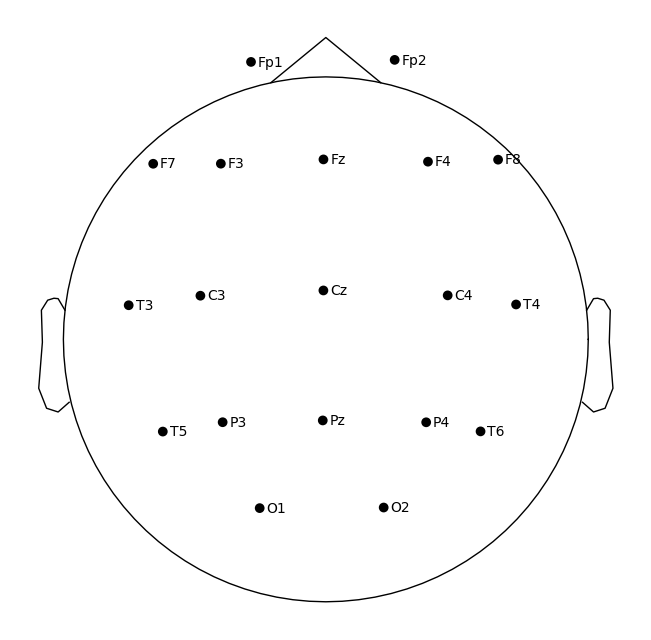

In [59]:
# Plot the scalp layout
montage = raw_001.plot_sensors(show_names=True)

montage.savefig("Montage Layout.pdf", dpi=300, bbox_inches='tight')

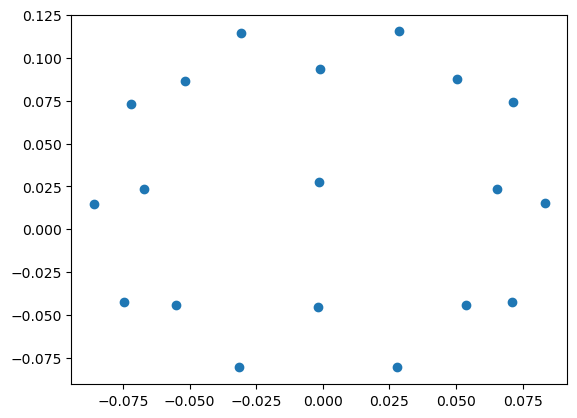

In [61]:
# Extract the 2D coordinates of the EEG channels
xy = np.array([ch["loc"][:2] for ch in raw_001.info["chs"]])
plt.scatter(xy[:, 0], xy[:, 1])
plt.savefig("2D Channel Coordinates.pdf", dpi=300, bbox_inches='tight')
plt.show()

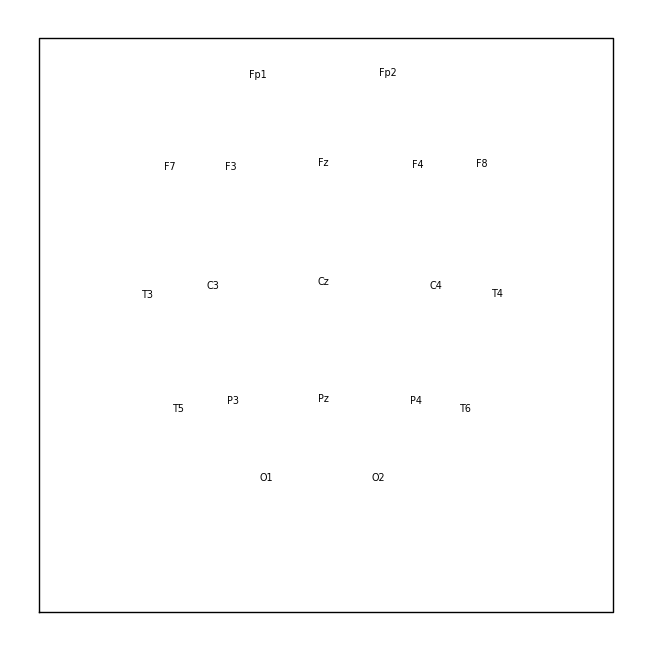

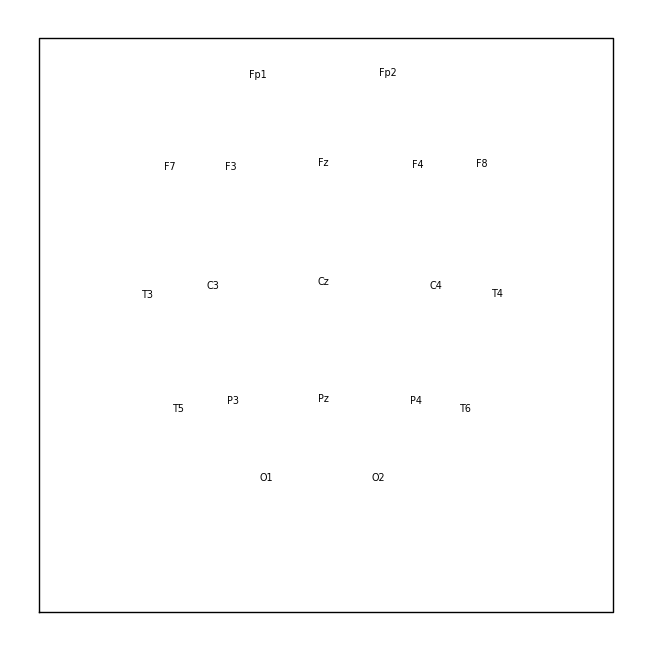

In [62]:
# Create a Layout object that contains sensor positions
layout_from_raw = mne.channels.make_eeg_layout(raw_001.info)
layout_from_raw.plot()

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


c:\Users\xiaox\anaconda3\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


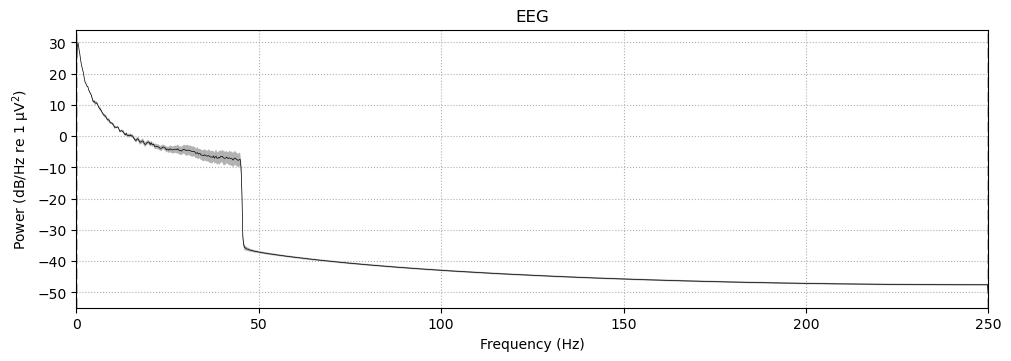

In [176]:
spectrum = raw_001.compute_psd()
spectrum.plot(average=True, picks="data", exclude="bads", amplitude=False)

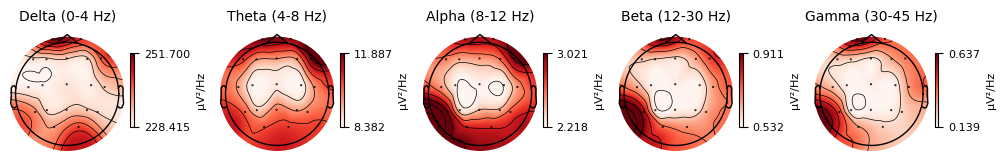

In [178]:
# Plot spectral power estimates across sensors as a scalp topography 
topo = spectrum.plot_topomap()  # The default parameters will plot five frequency bands (δ, θ, α, β, γ)
topo.savefig("Topographic Map.pdf", dpi=300, bbox_inches='tight')

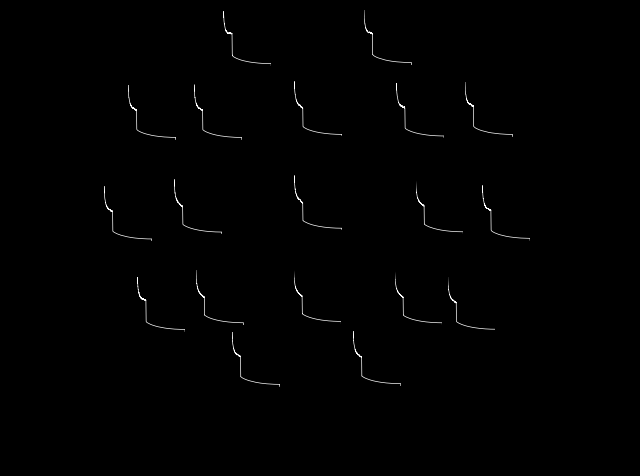

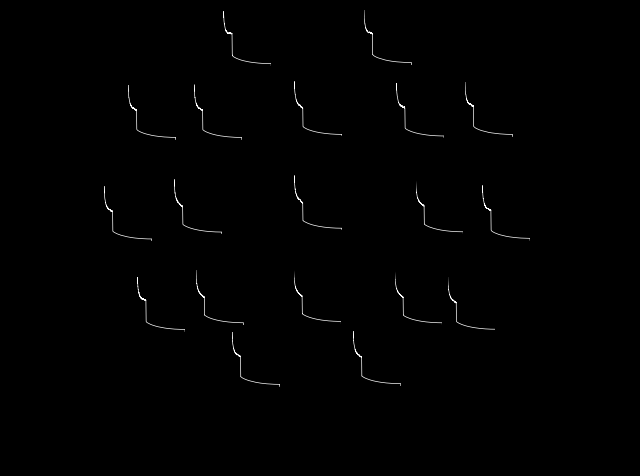

In [180]:
# Alternative way to plot PSD for every sensor on its own axes
spectrum.plot_topo()

In [181]:
# Group the channels into regions
regions = {
    "frontal": ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"],
    "central": ["C3", "C4", "Cz"],
    "parietal": ["P3", "P4", "Pz"],
    "temporal": ["T3", "T4", "T5", "T6"],
    "occipital": ["O1", "O2"],
}

In [4]:
# Extract regularly spaced spans of data
epochs_001 = mne.make_fixed_length_epochs(raw_001, duration=4.0, overlap=2.0, preload=True)  # preload=True: force loading the data into memory
print(epochs_001)
print(epochs_001.events[:10])

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 298 events and 2000 original time points ...
0 bad epochs dropped
<Epochs | 298 events (all good), 0 – 3.998 s (baseline off), ~86.4 MiB, data loaded,
 '1': 298>
[[   0    0    1]
 [1000    0    1]
 [2000    0    1]
 [3000    0    1]
 [4000    0    1]
 [5000    0    1]
 [6000    0    1]
 [7000    0    1]
 [8000    0    1]
 [9000    0    1]]


In [183]:
print(epochs_001.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, ...
 chs: 19 EEG
 custom_ref_applied: False
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
>


In [63]:
# Extract the epoched data as NumPy array
array_epochs = epochs_001.get_data()
print(array_epochs.shape)  # （n_epochs, n_channels, n_times per epoch) 2000 samples = 500 Hz * 4 s

(298, 19, 2000)


In [64]:
# Convert epochs into Pandas DataFrame
df_epochs = epochs_001.to_data_frame()
print(df_epochs.shape)  # each row is a sample within an epoch: 596000 = 298 epochs * 4 s * 500 Hz

(596000, 22)


In [66]:
df_epochs[:10]

,time,condition,epoch,Fp1,Fp2,F3,F4,C3,C4,P3,...,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,0.000,1,0,-33.716686,-25.142326,-10.501626,-15.470965,-14.639780,-18.083931,-12.670144,...,-14.500907,-21.664469,-17.408562,-15.743222,-15.870240,-12.270000,-18.645056,-16.640219,-15.989630,-15.898245
1,0.002,1,0,-28.189100,-20.730621,-10.805439,-13.357321,-13.841861,-15.904325,-11.895370,...,-13.384614,-18.855465,-14.015569,-15.190090,-14.149742,-13.692374,-16.790701,-14.803726,-14.482277,-14.147045
2,0.004,1,0,-22.796139,-16.693195,-11.653964,-11.569100,-13.329861,-13.841828,-11.468915,...,-12.559989,-16.338762,-11.195667,-14.826118,-13.128342,-15.350288,-15.361226,-13.299286,-13.112459,-12.649577
3,0.006,1,0,-18.145367,-13.420150,-12.855981,-10.171793,-13.044628,-12.095045,-11.322964,...,-12.052039,-14.305224,-9.178638,-14.566225,-12.879128,-16.850992,-14.529299,-12.216455,-11.933325,-11.532134
4,0.008,1,0,-14.718303,-11.144460,-14.124736,-9.136185,-12.878322,-10.791430,-11.326547,...,-11.807705,-12.845049,-8.007304,-14.309454,-13.280541,-17.802584,-14.327282,-11.534676,-10.953032,-10.835276
5,0.010,1,0,-12.785983,-9.913951,-15.151831,-8.368348,-12.716713,-9.969612,-11.333759,...,-11.724336,-11.949924,-7.547460,-13.983756,-14.053926,-17.926041,-14.644756,-11.141476,-10.150707,-10.518002
6,0.012,1,0,-12.366426,-9.604193,-15.689882,-7.755094,-12.482632,-9.582129,-11.235567,...,-11.693571,-11.537123,-7.543262,-13.581854,-14.843621,-17.146044,-15.264096,-10.875755,-9.499329,-10.482832
7,0.014,1,0,-13.227614,-9.962382,-15.618987,-7.209281,-12.165816,-9.518820,-10.998749,...,-11.645902,-11.483436,-7.698645,-13.174447,-15.313989,-15.632240,-15.924466,-10.581396,-8.986267,-10.612638
8,0.016,1,0,-14.938907,-10.671926,-14.978816,-6.700028,-11.828238,-9.642767,-10.677758,...,-11.579145,-11.658363,-7.760572,-12.892584,-15.240504,-13.773209,-16.394192,-10.155222,-8.622709,-10.806151
9,0.018,1,0,-16.956139,-11.420069,-13.957000,-6.260224,-11.585073,-9.827138,-10.397852,...,-11.563351,-11.948369,-7.583464,-12.885415,-14.565970,-12.088778,-16.532812,-9.576736,-8.439987,-11.003348


In [67]:
# Set epochs as the index 
df_epochs_2 = epochs_001.to_data_frame(index="epoch")
df_epochs_2.iloc[:10]

,time,condition,Fp1,Fp2,F3,F4,C3,C4,P3,P4,...,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
epoch,,,,,,,,,,,,,,,,,,,,,
0,0.000,1,-33.716686,-25.142326,-10.501626,-15.470965,-14.639780,-18.083931,-12.670144,-15.455706,...,-14.500907,-21.664469,-17.408562,-15.743222,-15.870240,-12.270000,-18.645056,-16.640219,-15.989630,-15.898245
0,0.002,1,-28.189100,-20.730621,-10.805439,-13.357321,-13.841861,-15.904325,-11.895370,-13.762712,...,-13.384614,-18.855465,-14.015569,-15.190090,-14.149742,-13.692374,-16.790701,-14.803726,-14.482277,-14.147045
0,0.004,1,-22.796139,-16.693195,-11.653964,-11.569100,-13.329861,-13.841828,-11.468915,-12.353460,...,-12.559989,-16.338762,-11.195667,-14.826118,-13.128342,-15.350288,-15.361226,-13.299286,-13.112459,-12.649577
0,0.006,1,-18.145367,-13.420150,-12.855981,-10.171793,-13.044628,-12.095045,-11.322964,-11.337563,...,-12.052039,-14.305224,-9.178638,-14.566225,-12.879128,-16.850992,-14.529299,-12.216455,-11.933325,-11.532134
0,0.008,1,-14.718303,-11.144460,-14.124736,-9.136185,-12.878322,-10.791430,-11.326547,-10.731927,...,-11.807705,-12.845049,-8.007304,-14.309454,-13.280541,-17.802584,-14.327282,-11.534676,-10.953032,-10.835276
0,0.010,1,-12.785983,-9.913951,-15.151831,-8.368348,-12.716713,-9.969612,-11.333759,-10.469683,...,-11.724336,-11.949924,-7.547460,-13.983756,-14.053926,-17.926041,-14.644756,-11.141476,-10.150707,-10.518002
0,0.012,1,-12.366426,-9.604193,-15.689882,-7.755094,-12.482632,-9.582129,-11.235567,-10.430983,...,-11.693571,-11.537123,-7.543262,-13.581854,-14.843621,-17.146044,-15.264096,-10.875755,-9.499329,-10.482832
0,0.014,1,-13.227614,-9.962382,-15.618987,-7.209281,-12.165816,-9.518820,-10.998749,-10.486097,...,-11.645902,-11.483436,-7.698645,-13.174447,-15.313989,-15.632240,-15.924466,-10.581396,-8.986267,-10.612638
0,0.016,1,-14.938907,-10.671926,-14.978816,-6.700028,-11.828238,-9.642767,-10.677758,-10.536223,...,-11.579145,-11.658363,-7.760572,-12.892584,-15.240504,-13.773209,-16.394192,-10.155222,-8.622709,-10.806151


In [68]:
# Long-format DataFrame
long_df = epochs_001.to_data_frame(time_format=None, index="epoch", long_format=True)
long_df.iloc[:10]

Converting "condition" to "category"...
Converting "channel" to "category"...
Converting "ch_type" to "category"...


,condition,time,channel,ch_type,value
epoch,,,,,
0,1,0.0,Fp1,eeg,-33.716686
0,1,0.0,Fp2,eeg,-25.142326
0,1,0.0,F3,eeg,-10.501626
0,1,0.0,F4,eeg,-15.470965
0,1,0.0,C3,eeg,-14.639780
0,1,0.0,C4,eeg,-18.083931
0,1,0.0,P3,eeg,-12.670144
0,1,0.0,P4,eeg,-15.455706
0,1,0.0,O1,eeg,-14.112548


Black line = average across all epochs.

Grey shading = variability across epochs (±1 standard deviation).

In task-based EEG, this would show the evoked response. In resting-state, it just shows the grand mean signal across time, which should hover near zero (no time-locking).

No huge blocks of red/blue → good, means no massive artifacts dominating whole epochs.

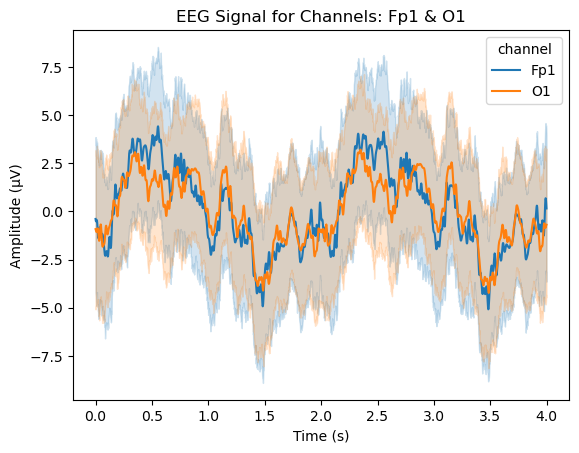

In [69]:
# Plot mean signal across epochs per channel with confidence intervals
plt.figure()
channels = ["Fp1", "O1"]
data = long_df.query("channel in @channels").copy()

# Convert channel column 
data["channel"] = data["channel"].astype(str)
data.reset_index(drop=True, inplace=True)

sns.lineplot(x="time", y="value", hue="channel", data=data)
plt.title("EEG Signal for Channels: Fp1 & O1")
plt.ylabel("Amplitude (µV)")
plt.xlabel("Time (s)")
plt.tight_layout
plt.show()

In [70]:
# Extract times between 100 and 107ms on channel O2 through F8
print(df_epochs.loc[slice(100, 107), "O2":"F8"])

            O2         F7         F8
100   8.120568  -4.545008 -12.342515
101   9.492079  -6.930362 -13.335039
102  10.567532  -8.660812 -13.646436
103  10.975758  -9.699057 -13.477596
104  10.458570 -10.069875 -13.030828
105   8.938228  -9.854134 -12.470066
106   6.543186  -9.178452 -11.898002
107   3.582864  -8.202209 -11.355401


In [71]:
# Select channels in epochs
channel_epoch = epochs_001.copy().pick("Fp1")

In [72]:
# Select epochs by index
print(epochs_001[:10])  # epochs 0-9
print(epochs_001[1:8:2])  # epochs 1, 3, 5, 7

<Epochs | 10 events (all good), 0 – 3.998 s (baseline off), ~2.9 MiB, data loaded,
 '1': 10>
<Epochs | 4 events (all good), 0 – 3.998 s (baseline off), ~1.2 MiB, data loaded,
 '1': 4>


In [73]:
# select epochs in the time domain
shorter_epochs = epochs_001.copy().crop(tmin=-0.1, tmax=0.1, include_tmax=True)
for name, obj in dict(Original=epochs_001, Cropped=shorter_epochs).items():
    print(f"{name} epochs has {obj.get_data(copy=False).shape[-1]} time samples.")

Original epochs has 2000 time samples.
Cropped epochs has 51 time samples.


C:\Users\xiaox\AppData\Local\Temp\ipykernel_29064\3361866945.py:2: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (0 s)
  shorter_epochs = epochs_001.copy().crop(tmin=-0.1, tmax=0.1, include_tmax=True)


In [75]:
# Save and load Epochs oject
epochs_001.save("saved_epo.fif", overwrite=True)
epochs_from_file = mne.read_epochs("saved_epo.fif", preload=False)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Reading d:\thesis_codes\notebooks\saved_epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated


In [76]:
# Iterate over Epochs (gets arrays rather than single-trial Epochs objects)
for epoch in epochs_001[:3]:
    print(type(epoch))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [77]:
# How to iterate over Epochs objects
for index in range(3):
    print(type(epochs_001[index]))

<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>


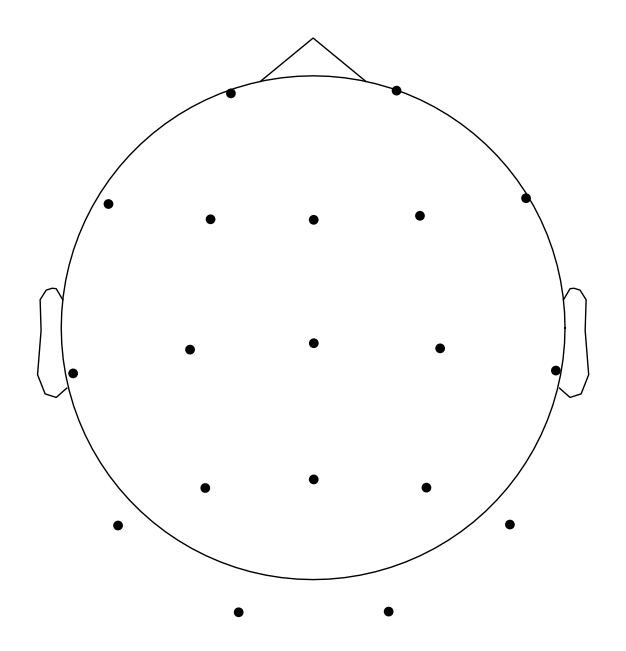

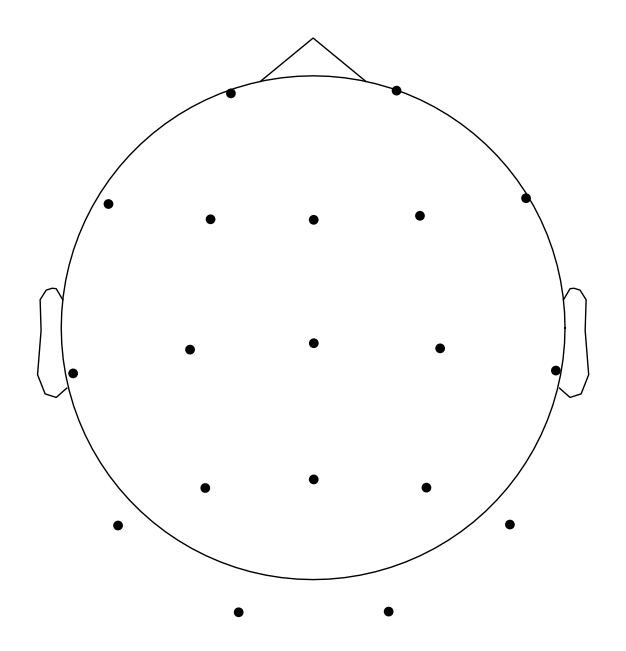

In [78]:
# Plot the sensor locations
epochs_001.plot_sensors(kind="topomap", ch_type="all")

In [79]:
raw_001.ch_names

['Fp1',
 'Fp2',
 'F3',
 'F4',
 'C3',
 'C4',
 'P3',
 'P4',
 'O1',
 'O2',
 'F7',
 'F8',
 'T3',
 'T4',
 'T5',
 'T6',
 'Fz',
 'Cz',
 'Pz']

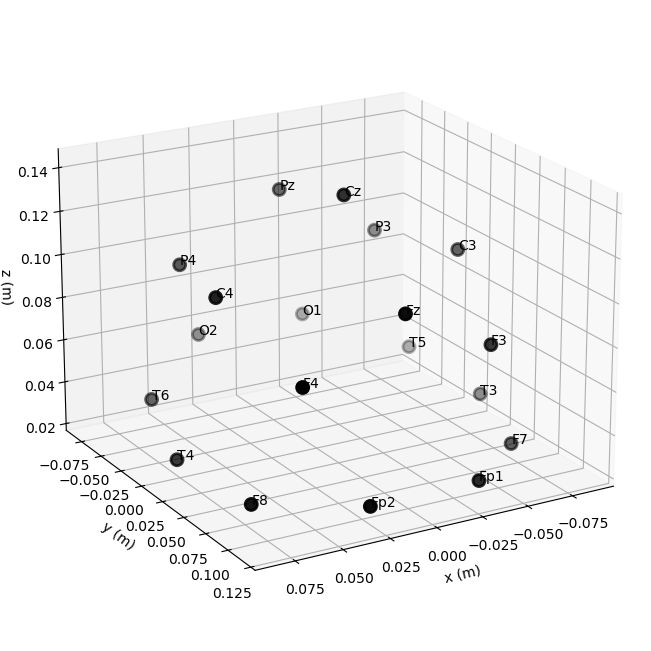

In [80]:
# Plot the 3D sensor layout
raw_001.set_montage("standard_1020")
montage_3d = raw_001.plot_sensors(kind="3d", show_names=True, ch_type="eeg", show=False)
montage_3d.gca().view_init(azim=60, elev=20)
montage_3d.savefig("3D Sensor Layout.pdf", dpi=300, bbox_inches='tight')
plt.show()


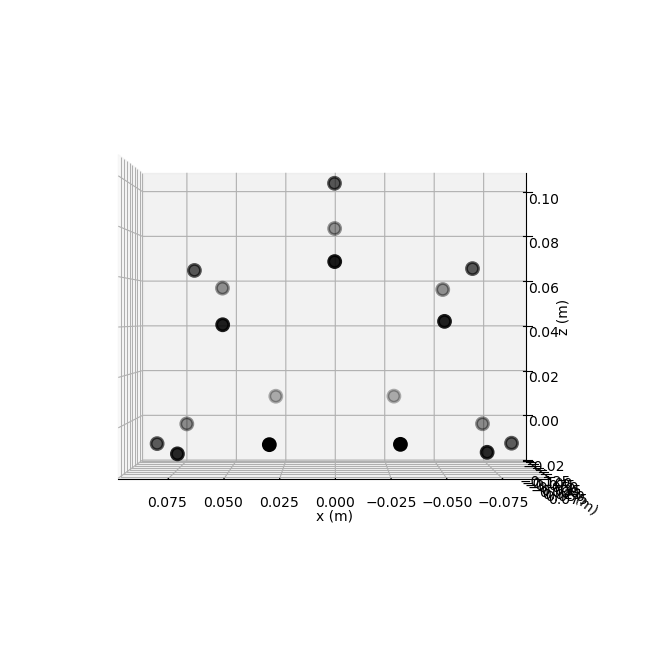

In [81]:
channel_3d = epochs_001.plot_sensors(kind="3d", ch_type="all")

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


c:\Users\xiaox\anaconda3\envs\thesis\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


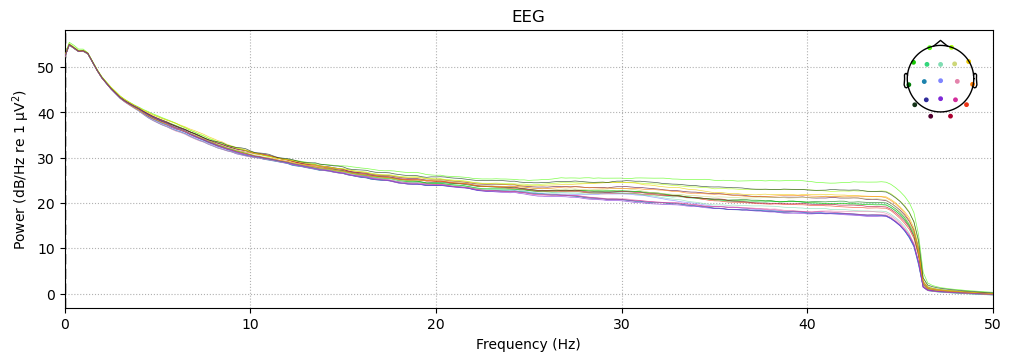

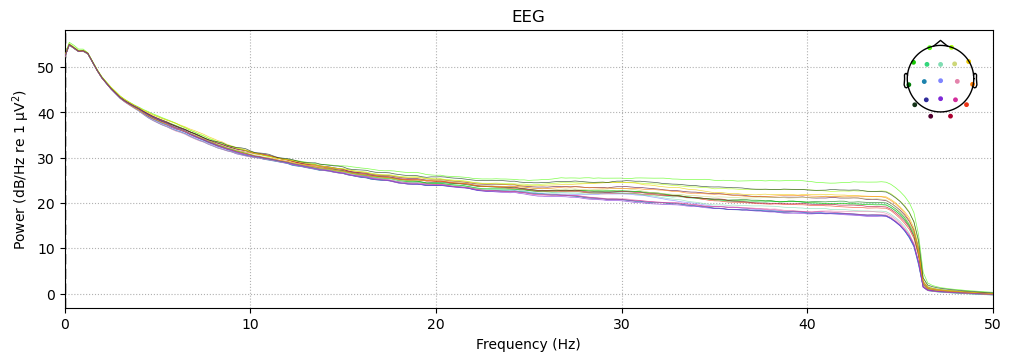

In [82]:
# Plot the power spectrum of Epochs
epochs_001.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


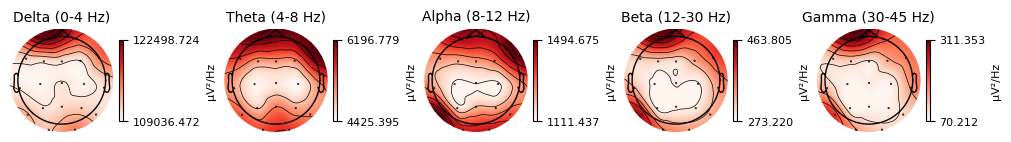

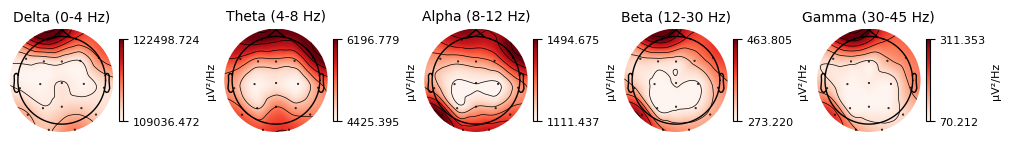

In [86]:
# Plot spectral power estimates across sensors as a scalp topography
spectrum_epochs = epochs_001.compute_psd()
spectrum_epochs.plot_topomap()

Averaging across epochs before plotting...


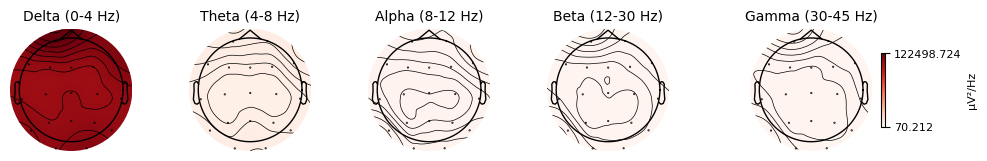

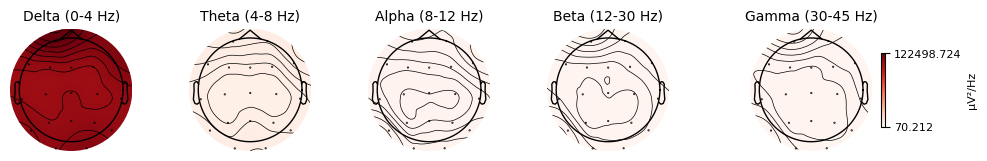

In [87]:
# Use joint colorbar
spectrum_epochs.plot_topomap(vlim="joint")

Averaging across epochs before plotting...


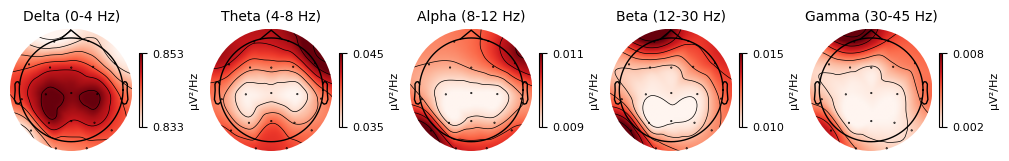

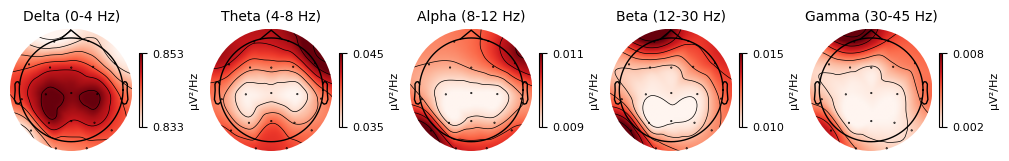

In [88]:
# Normalise the power estimates by dividing by the total power across all frequencies 
spectrum_epochs.plot_topomap(normalize=True)

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


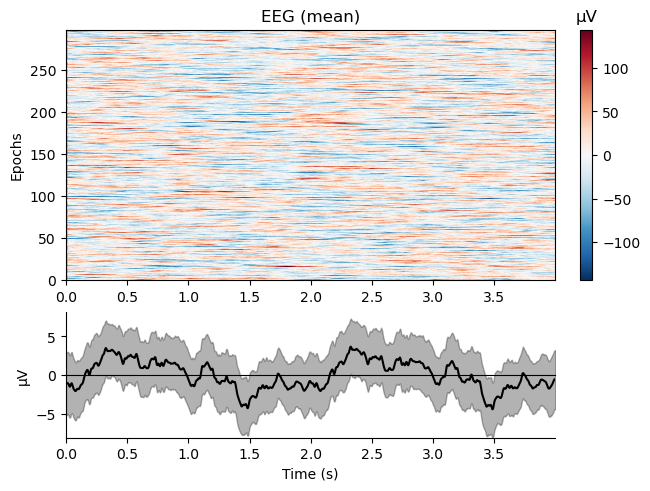

[<Figure size 640x480 with 3 Axes>]

In [89]:
# Plot epochs as an image map
epochs_001.plot_image(combine="mean")

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated
combining channels using GFP (eeg channels)


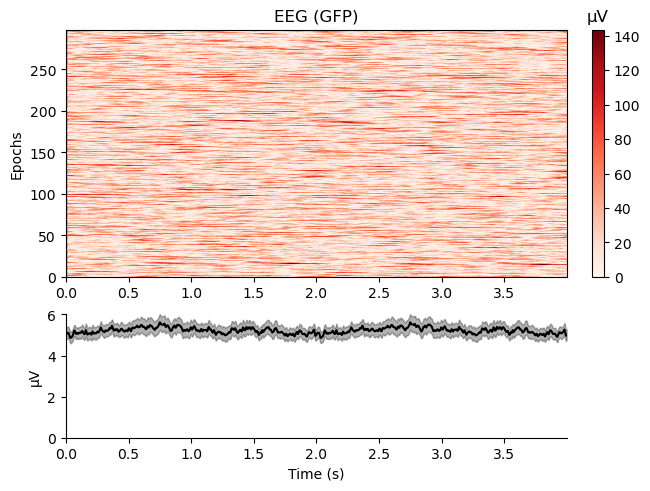

[<Figure size 640x480 with 3 Axes>]

In [90]:
# Plot the global field power 
epochs_001.plot_image(combine="gfp")

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated


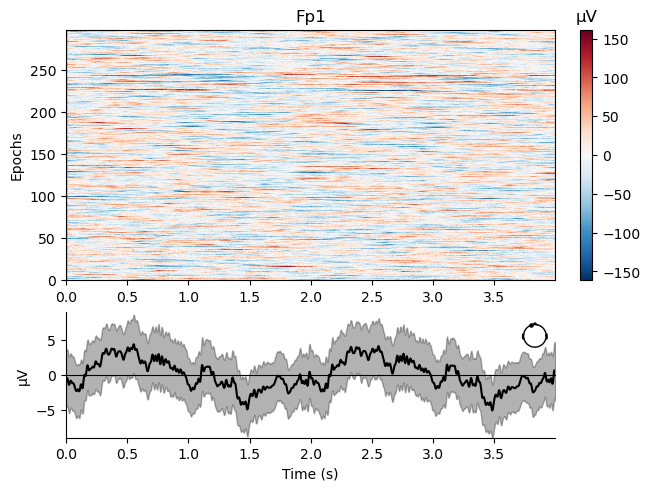

[<Figure size 640x480 with 4 Axes>]

In [91]:
# Plot image map for individual sensor
epochs_001.plot_image(picks="Fp1")

Not setting metadata
298 matching events found
No baseline correction applied
0 projection items activated


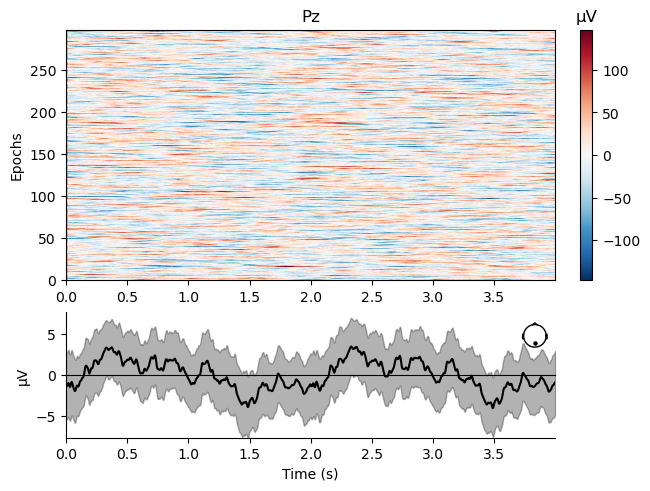

[<Figure size 640x480 with 4 Axes>]

In [92]:
epochs_001.plot_image(picks="Pz")

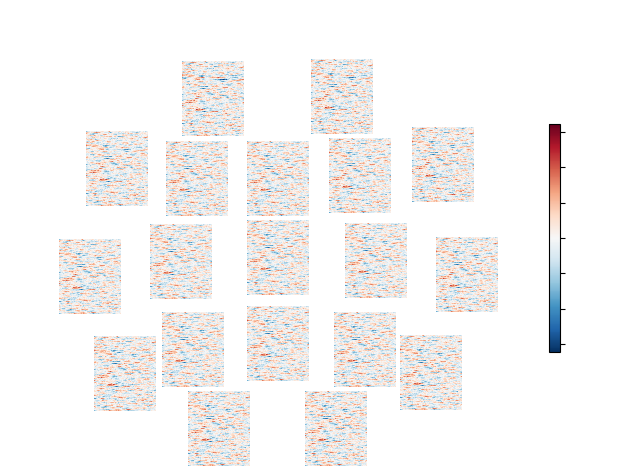

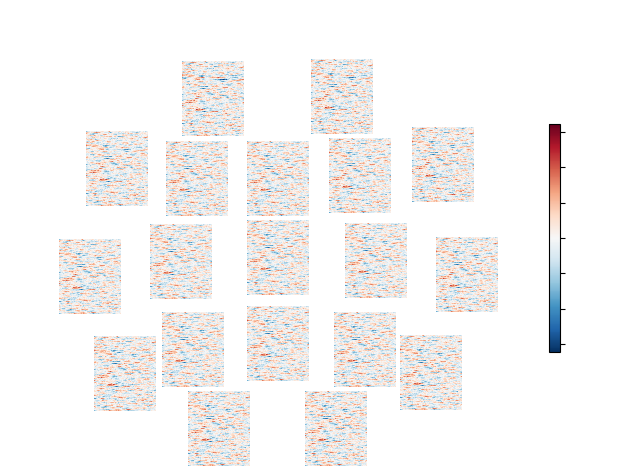

In [93]:
# Plot an image map for all sensors 
epochs_001.plot_topo_image(fig_facecolor="w")

Effective window size : 4.000 (s)
(298, 19, 179)
(179,)


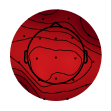

(<matplotlib.image.AxesImage at 0x24ebf560e50>,
 <matplotlib.contour.QuadContourSet at 0x24ebf2eeb90>)

In [94]:
# Compute PSD using Welch method
psd = epochs_001.compute_psd(method="welch", fmin=0.5, fmax=45)

# Get the data and the frequencies 
psds, freqs = psd.get_data(return_freqs=True)
print(psds.shape)
print(freqs.shape)

# Extract alpha power 
alpha_mask = (freqs >=8) & (freqs <= 13)
alpha_power = psds[:, :, alpha_mask].mean(axis=-1)  # (n_epochs, n_channels)

# Average over epochs
mean_alpha = alpha_power.mean(axis=0)

# Plot scalp alpha power
plot_topomap(mean_alpha, epochs_001.info, sphere=0.07)

2D topographic heatmap

Red = higher alpha power

Darker/black = lower alpha power

Black dots = EEG electrode positions (e.g., Fp1, Fz, Cz, etc.)

In [95]:
# get the index of channel O1
o1_index = psd.info['ch_names'].index('O1')  
print(o1_index)

8


In [96]:
# Extract alpha power at channel O1
mean_alpha_o1 = mean_alpha[o1_index]
print(mean_alpha_o1)

2.5101720618950922e-12


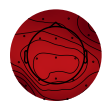

(<matplotlib.image.AxesImage at 0x24ebe9da710>,
 <matplotlib.contour.QuadContourSet at 0x24ebe8dcd50>)

In [97]:
# Compute relative alpha power
total_power = psds.sum(axis=-1, keepdims=True)
rel_alpha_power = alpha_power / total_power[:, :, 0]
mean_rel_alpha = rel_alpha_power.mean(axis=0)
plot_topomap(mean_rel_alpha, epochs_001.info, sphere=0.07)